In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set chart style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load the datasets
customers = pd.read_excel("FinTrust_Customer_Data.xlsx")
transactions = pd.read_excel("FinTrust_Transaction_Data.xlsx")

# Fill the missing blanks in Device and Location
transactions["Device_Type"] = transactions["Device_Type"].fillna("Unknown")
transactions["Location"] = transactions["Location"].fillna("Unknown")

# Merge them together using Customer_ID
df = pd.merge(transactions, customers, on="Customer_ID", how="left")
print(f"Data loaded successfully! Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Data loaded successfully! Rows: 12000, Columns: 22


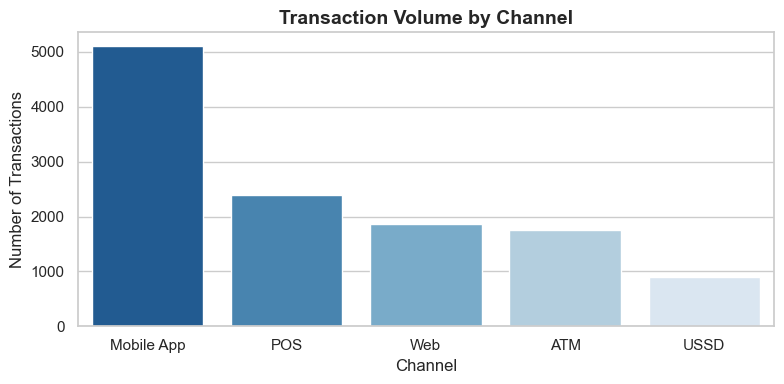

In [4]:
channel_counts = df["Channel"].value_counts()

plt.figure(figsize=(8, 4))
# We added hue and legend=False here to fix the warning
sns.barplot(x=channel_counts.index, y=channel_counts.values, hue=channel_counts.index, palette="Blues_r", legend=False)
plt.title("Transaction Volume by Channel", fontsize=14, fontweight="bold")
plt.xlabel("Channel")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

Transaction Volume by channel
The transaction count across Mobile App(5102), POS((2,392), Web(1869), ATM(1,747) and USSD(889). It reveals which digital channels bear the heaviest operational traffic.
Business Insight: Mobile App is the dominant interface, infrastructure investments and uptime monitoring must prioritize the mobile backend to prevent widespread operational failure. 

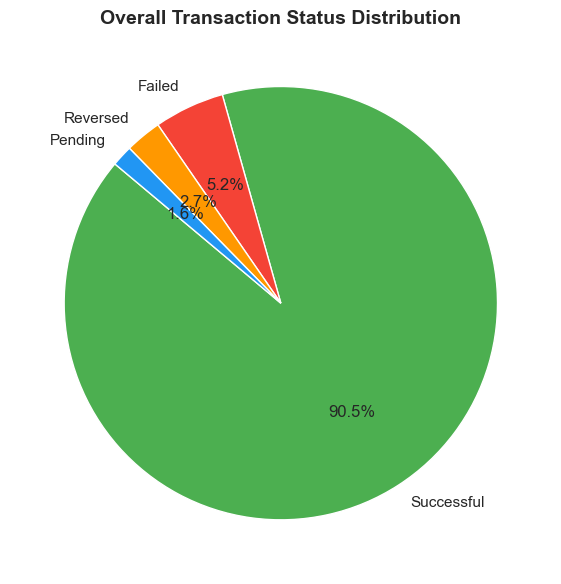

In [10]:
status_counts = df["Transaction_Status"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(status_counts.values, labels=status_counts.index, autopct="%1.1f%%", 
        colors=["#4CAF50", "#F44336", "#FF9800", "#2196F3"], startangle=140)
plt.title("Overall Transaction Status Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


The proportion of Successful (90.5%), Failed (5.3%), Reversed (2.7%), and Pending (1.6%) transactions. It measures system reliability and overall payment failure rates.
Business Insights: Nearly 9.5% of attempts face operational friction. This pinpoints an immediate driver of customer support tickets that needs engineering attention.

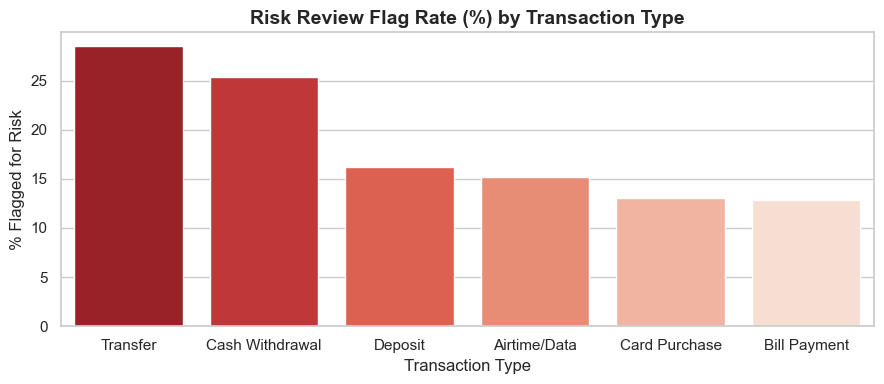

In [6]:
risk_by_type = df.groupby("Transaction_Type")["Risk_Review_Flag"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=risk_by_type.index, y=risk_by_type.values, hue=risk_by_type.index, palette="Reds_r", legend=False)
plt.title("Risk Review Flag Rate (%) by Transaction Type", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("% Flagged for Risk")
plt.tight_layout()
plt.show()

Transfers (28.5%) and Cash Withdrawals (25.3%) have the highest risk flags, compared to Card Purchases (13.0%) and Bill Payments (12.8%).It clarifies which banking actions trigger fraud or compliance rules most frequently.
Business insight: Fraud prevention rules should focus heavily on outgoing peer-to-peer transfers and ATM cash points rather than standard merchant purchases

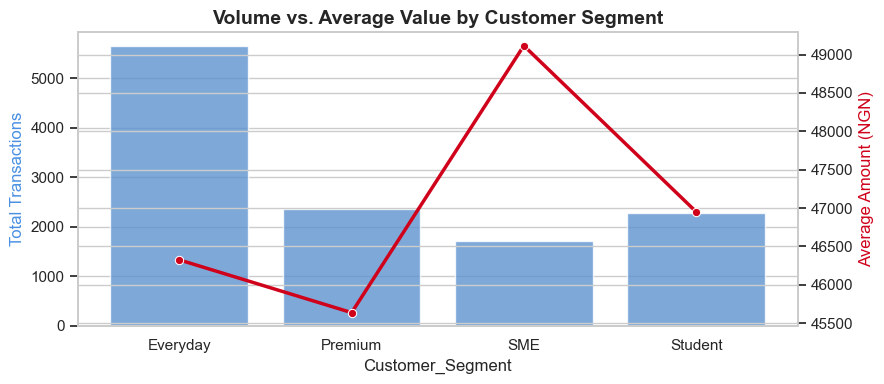

In [7]:
segment_summary = df.groupby("Customer_Segment").agg(
    Total_Volume=("Transaction_ID", "count"), Avg_Amount=("Amount_NGN", "mean")).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 4))
sns.barplot(data=segment_summary, x="Customer_Segment", y="Total_Volume", ax=ax1, color="#4A90E2", alpha=0.8)
ax1.set_ylabel("Total Transactions", color="#4A90E2")

ax2 = ax1.twinx()
sns.lineplot(data=segment_summary, x="Customer_Segment", y="Avg_Amount", ax=ax2, color="#D0021B", marker="o", linewidth=2.5)
ax2.set_ylabel("Average Amount (NGN)", color="#D0021B")

plt.title("Volume vs. Average Value by Customer Segment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

The Everyday segment leads transaction volume (5,644), while SMEs exhibit the highest average transaction value (~49,115 NGN). It distinguishes pure volume drivers from high-value revenue drivers.
Business insight: Everyday users require low-friction consumer features, while SME customers require enterprise support and higher transaction limits.

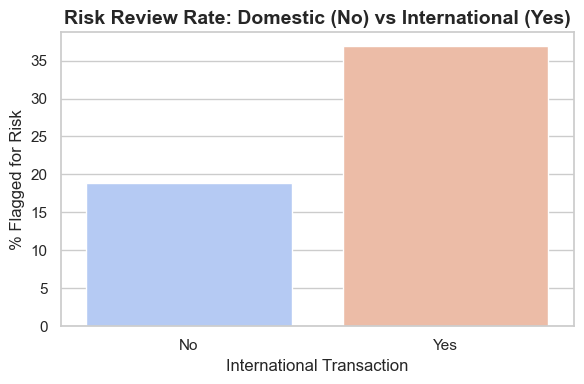

In [8]:
risk_intl = df.groupby("International_Transaction")["Risk_Review_Flag"].apply(lambda x: (x == "Yes").mean() * 100).reset_index(name="Risk_Percentage")

plt.figure(figsize=(6, 4))
sns.barplot(data=risk_intl, x="International_Transaction", y="Risk_Percentage", hue="International_Transaction", palette="coolwarm", legend=False)
plt.title("Risk Review Rate: Domestic (No) vs International (Yes)", fontsize=14, fontweight="bold")
plt.xlabel("International Transaction")
plt.ylabel("% Flagged for Risk")
plt.tight_layout()
plt.show()

International transactions are flagged at 36.9% compared to 18.9% for domestic transactions.This highlights cross-border financial vulnerability.
Business insight: Cross-border payments carry nearly 2x the compliance burden, justifying the implementation of targeted identity checks or real-time verification gateways.

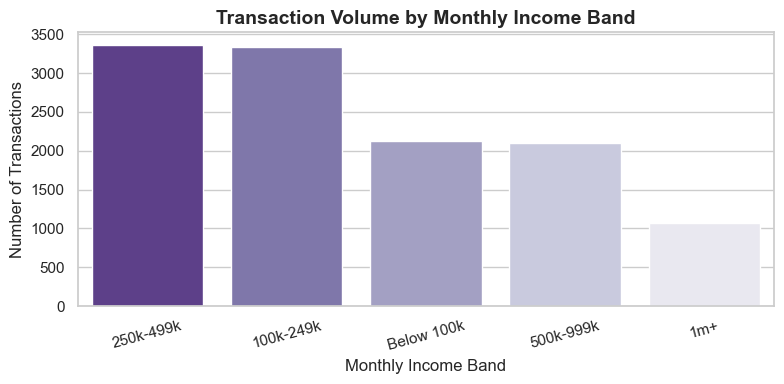

In [9]:
income_volume = df["Monthly_Income_Band"].value_counts().reset_index()
income_volume.columns = ["Income_Band", "Transaction_Count"]

plt.figure(figsize=(8, 4))
sns.barplot(data=income_volume, x="Income_Band", y="Transaction_Count", hue="Income_Band", palette="Purples_r", legend=False)
plt.title("Transaction Volume by Monthly Income Band", fontsize=14, fontweight="bold")
plt.xlabel("Monthly Income Band")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

The total number of transactions grouped by customers' self-reported monthly income bands. It reveals which financial demographic relies on the FinTrust platform the most for their daily banking.
Business insight: By identifying the most active income bracket, FinTrust can tailor its marketing spend and design specific credit or loan products that perfectly match the financial capacity of its core user base.

In [11]:
import pandas as pd

# 1. Load the original datasets (ensure the file names match yours exactly)
customers = pd.read_excel('FinTrust_Customer_Data.xlsx')
transactions = pd.read_excel('FinTrust_Transaction_Data.xlsx')

# 2. Merge the two datasets together using Customer_ID
merged_data = pd.merge(transactions, customers, on='Customer_ID', how='left')

# 3. Clean missing values as specified by the data dictionary
merged_data['Device_Type'] = merged_data['Device_Type'].fillna('Unknown')
merged_data['Location'] = merged_data['Location'].fillna('Unknown')

# 4. Save the final combined dataset as a CSV file
merged_data.to_csv('FinTrust_Cleaned_Dataset.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
